In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv('../../datasets/Advertising.csv')
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df['Advertising_Spend'] = df['TV'] + df['Radio'] + df['Newspaper']
df.head()

,TV,Radio,Newspaper,Sales,Advertising_Spend
0,230.1,37.8,69.2,22.1,337.1
1,44.5,39.3,45.1,10.4,128.9
2,17.2,45.9,69.3,9.3,132.4
3,151.5,41.3,58.5,18.5,251.3
4,180.8,10.8,58.4,12.9,250.0


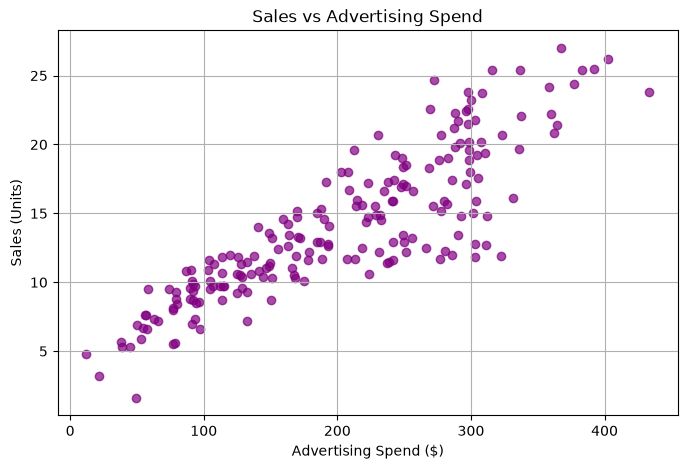

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Advertising_Spend'], df['Sales'], color='purple', alpha=0.7)
plt.title('Sales vs Advertising Spend')
plt.xlabel('Advertising Spend ($)')
plt.ylabel('Sales (Units)')
plt.grid(True)
plt.show()

In [4]:
X = df[['Advertising_Spend']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.05]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Advertising_Spend']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.199
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [5]:
b_0 = model.intercept_
b_1 = model.coef_[0]

print(f'Regression Equation: h(x) = {b_0:.4f} + {b_1:.4f} * x')
print(f'Intercept (b_0): {b_0:.4f}')
print(f'Slope (b_1): {b_1:.4f}')
print(f'Interpretation: The intercept b_0 represents baseline sales of {b_0:.4f} units if zero budget is spent on advertising. The slope b_1 means that for each additional dollar spent on advertising, sales increase by {b_1:.4f} units.')

Regression Equation: h(x) = 4.1991 + 0.0490 * x
Intercept (b_0): 4.1991
Slope (b_1): 0.0490
Interpretation: The intercept b_0 represents baseline sales of 4.1991 units if zero budget is spent on advertising. The slope b_1 means that for each additional dollar spent on advertising, sales increase by 0.0490 units.


In [6]:
new_budgets = pd.DataFrame({'Advertising_Spend': [100.0, 250.0, 400.0]})
predictions = model.predict(new_budgets)

for budget, pred in zip(new_budgets['Advertising_Spend'], predictions):
    print(f'Advertising Budget:  -> Predicted Sales: {pred:.2f} units')

Advertising Budget:  -> Predicted Sales: 9.09 units
Advertising Budget:  -> Predicted Sales: 16.44 units
Advertising Budget:  -> Predicted Sales: 23.78 units


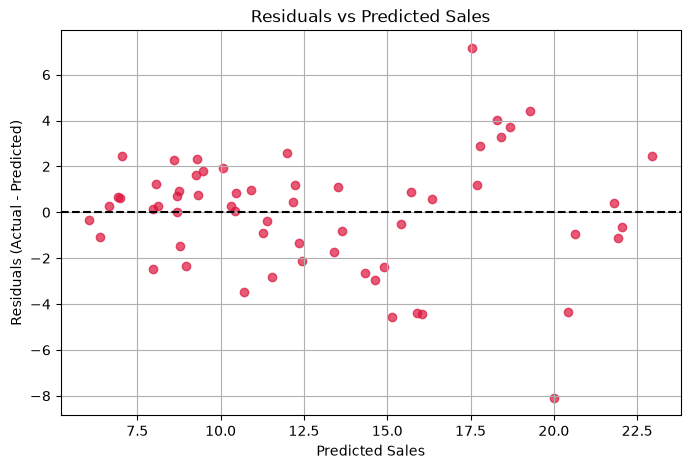

Discussion: The residual plot shows a noticeable non-linear pattern rather than pure random scatter around zero. While a simple linear model captures the general upward trend, advertising spend exhibits diminishing marginal returns, suggesting a polynomial or log transformation would fit the data better.


In [7]:
y_pred = model.predict(X_test)
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, color='crimson', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residuals vs Predicted Sales')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True)
plt.show()

print('Discussion: The residual plot shows a noticeable non-linear pattern rather than pure random scatter around zero. While a simple linear model captures the general upward trend, advertising spend exhibits diminishing marginal returns, suggesting a polynomial or log transformation would fit the data better.')